In [10]:
# This already assumes you ran 'pip install -e .' in the root directory
import os
import datetime
import sys

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [ ]:
# Import config loader and data loader
from config.config_loader import load_config
from data.data_loader import load_station_data
SELECTED_STATION = "Station2"

cfg = load_config()
station_data = load_station_data(cfg)

# print(f"Stations available: {list(station_data.keys())}")

df = station_data[SELECTED_STATION]
# df.head()
df.describe().transpose()

Loaded data from 6 stations.


,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,0.076135,8.328421e-01,0.0000,0.0000,0.0000,0.0000,53.3400
SWC_5,52560.0,0.180835,6.293782e-02,0.0790,0.1180,0.1810,0.2390,0.3200
SWC_10,52560.0,0.169187,5.643437e-02,0.0790,0.1130,0.1650,0.2200,0.3010
SWC_20,52560.0,0.220216,5.909819e-02,0.1230,0.1600,0.2220,0.2710,0.3640
SWC_50,52560.0,0.378658,8.687869e-02,0.2250,0.2970,0.3940,0.4620,0.5080
T_5,52560.0,22.318099,8.200431e+00,2.3600,15.5800,22.3900,28.7400,48.5300
T_10,52560.0,22.234559,7.890082e+00,3.9200,15.5900,22.3300,28.6900,43.4600
T_20,52560.0,22.221717,7.505304e+00,5.7500,15.6300,22.2800,28.7100,38.9100
T_50,52560.0,22.204293,6.544697e+00,9.2100,16.0800,21.9800,28.0625,34.7900
Tair,52560.0,19.083964,9.182934e+00,-10.7300,12.8800,20.4800,25.4100,42.1400


Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude',
       'Longitude'],
      dtype='object')


Text(0.5, 1.0, 'Time of day signal')

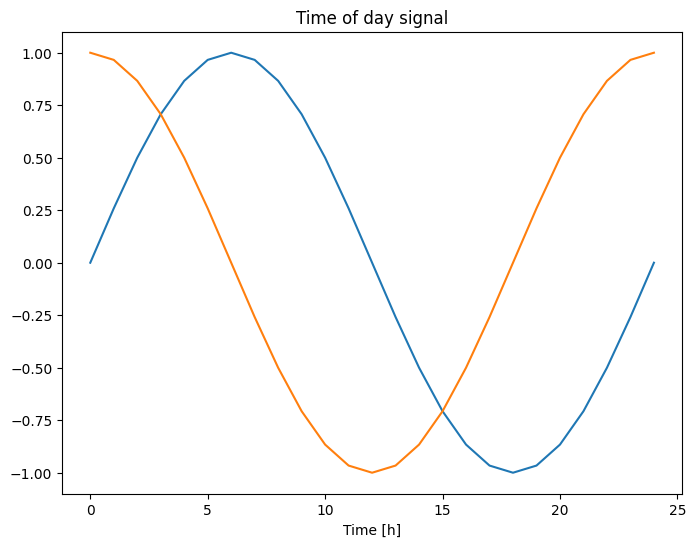

In [12]:
from data.feature_engineering import (
    consolidate_wind_vectors, add_periodic_time_features
)
print(df.columns)
df = consolidate_wind_vectors(df)
df = add_periodic_time_features(df)

plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [15]:
from data.feature_engineering import normalize_features
# Define constants from config at the top
DRY_RUN_ACTIVE = cfg["dry_run"]["active"]
DRY_RUN_TRAIN_ROWS = cfg["dry_run"]["train_rows"]
DRY_RUN_TEST_ROWS = cfg["dry_run"]["test_rows"]

# Define train/test split
train_df = df[df.index.year < 2020]
test_df = df[df.index.year == 2020]

# Apply Dry Run Settings
if DRY_RUN_ACTIVE:
    train_df = train_df.iloc[:DRY_RUN_TRAIN_ROWS]  # Fix: Slice correctly
    test_df = test_df.iloc[:DRY_RUN_TEST_ROWS]  # Fix: Slice correctly

train_df_scaled, test_df_scaled, scaler = normalize_features(train_df, test_df)
print("Final Features:", train_df_scaled.columns.tolist())


Final Features: ['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50', 'Tair', 'RH', 'Srad', 'Latitude', 'Longitude', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


In [ ]:
from data.windowing import generate_windows
from models.lstm_helpers import train_lstm, make_lstm_predictions
from models.model_manager import save_model

# Load constants from config
TARGET_COLUMN = cfg["model"]["target_column"]
WINDOW_SIZE = cfg["model"]["window_size"]
NUM_PREDICTIONS = cfg["model"]["num_predictions"]
EPOCHS = cfg["lstm"]["epochs"]
BATCH_SIZE = cfg["lstm"]["batch_size"]

# Prepare LSTM Data
X_train, y_train, X_test, y_test = generate_windows(
    train_df_scaled, test_df_scaled, TARGET_COLUMN, WINDOW_SIZE
)

# Train the LSTM model
model = train_lstm(
    X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE
)

# Optionally save the model
# save_model(model, SELECTED_STATION, "lstm")


In [ ]:
# Generate Predictions
lstm_predictions_scaled = make_lstm_predictions(
    model, test_df_scaled, TARGET_COLUMN, num_predictions=NUM_PREDICTIONS
)

# Ensure the correct number of predictions
num_preds = len(lstm_predictions_scaled)

# Create a placeholder DataFrame for inverse scaling
preds_placeholder = test_df_scaled.iloc[-num_preds:].copy()
preds_placeholder[TARGET_COLUMN] = lstm_predictions_scaled.reshape(-1)

# Ensure `scaler` is available for inverse transformation
inversed_array = scaler.inverse_transform(preds_placeholder)
inversed_df = pd.DataFrame(inversed_array, columns=preds_placeholder.columns, index=preds_placeholder.index)

# Extract final rescaled predictions
lstm_predictions_rescaled = inversed_df[TARGET_COLUMN].values

# Print sample predictions
print("First 5 rescaled predictions:", lstm_predictions_rescaled[:5])

In [ ]:

from evaluation_helpers import evaluate_model
y_actual_scaled = test_df_scaled[TARGET_COLUMN].iloc[-num_preds:].copy().values.reshape(-1)
# Create placeholder for actual
actual_placeholder = test_df_scaled.iloc[-num_preds:].copy()
actual_placeholder[TARGET_COLUMN] = y_actual_scaled
inversed_actual = scaler.inverse_transform(actual_placeholder)
inversed_actual_df = pd.DataFrame(inversed_actual,
                                  columns=actual_placeholder.columns,
                                  index=actual_placeholder.index)
y_actual = inversed_actual_df[TARGET_COLUMN].values

evaluate_model(y_actual, lstm_predictions_rescaled, model_name="LSTM")

In [ ]:
from plotting import plot_lstm_predictions
print(TARGET_COLUMN)
# Use rescaled predictions for plotting
plot_lstm_predictions(y_actual, lstm_predictions_rescaled, TARGET_COLUMN)
